# Data Preprocessing

Data preprocessing dilakukan untuk menyiapkan dataset sebelum masuk ke tahap feature engineering dan modeling. Pada tahap ini dilakukan transformasi data, encoding, dan feature scaling berdasarkan hasil exploratory data analysis (EDA).

# 1. Import Library

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler

# 2. Load Dataset

In [2]:
# membaca dataset hasil wrangling
df = pd.read_csv('../data/wrangled_data.csv')

In [3]:
# menampilkan 5 data pertama
df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2021-01-01,store_1,item_1,36,21.3,0,4,1
1,2021-01-02,store_1,item_1,36,21.3,0,5,1
2,2021-01-03,store_1,item_1,35,21.3,0,6,1
3,2021-01-04,store_1,item_1,41,21.3,0,0,1
4,2021-01-05,store_1,item_1,53,21.3,0,1,1


# 3. Menampilkan Informasi Dataset

In [4]:
# informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54750 entries, 0 to 54749
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      54750 non-null  object 
 1   store_id  54750 non-null  object 
 2   item_id   54750 non-null  object 
 3   sales     54750 non-null  int64  
 4   price     54750 non-null  float64
 5   promo     54750 non-null  int64  
 6   weekday   54750 non-null  int64  
 7   month     54750 non-null  int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 3.3+ MB


In [5]:
# statistik deskriptif
df.describe()

,sales,price,promo,weekday,month
count,54750.000000,54750.000000,54750.000000,54750.000000,54750.000000
mean,29.877881,56.077581,0.099233,3.005479,6.526027
std,14.689005,24.102496,0.298977,2.000467,3.447883
min,0.000000,12.200000,0.000000,0.000000,1.000000
25%,19.000000,37.620000,0.000000,1.000000,4.000000
50%,28.000000,58.620000,0.000000,3.000000,7.000000
75%,39.000000,76.300000,0.000000,5.000000,10.000000
max,114.000000,99.990000,1.000000,6.000000,12.000000


In [6]:
# statistik deskriptif
df.describe()

,sales,price,promo,weekday,month
count,54750.000000,54750.000000,54750.000000,54750.000000,54750.000000
mean,29.877881,56.077581,0.099233,3.005479,6.526027
std,14.689005,24.102496,0.298977,2.000467,3.447883
min,0.000000,12.200000,0.000000,0.000000,1.000000
25%,19.000000,37.620000,0.000000,1.000000,4.000000
50%,28.000000,58.620000,0.000000,3.000000,7.000000
75%,39.000000,76.300000,0.000000,5.000000,10.000000
max,114.000000,99.990000,1.000000,6.000000,12.000000


# 4. Menampilkan Kolom Numerik

In [7]:
# memilih kolom numerik
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

num_cols

Index(['sales', 'price', 'promo', 'weekday', 'month'], dtype='object')

# 5. Handling Outlier

Berdasarkan hasil exploratory data analysis (EDA), ditemukan beberapa outlier pada variabel penjualan. Namun jumlah outlier relatif kecil dan masih merepresentasikan kondisi data yang valid sehingga tidak dilakukan penghapusan data outlier.

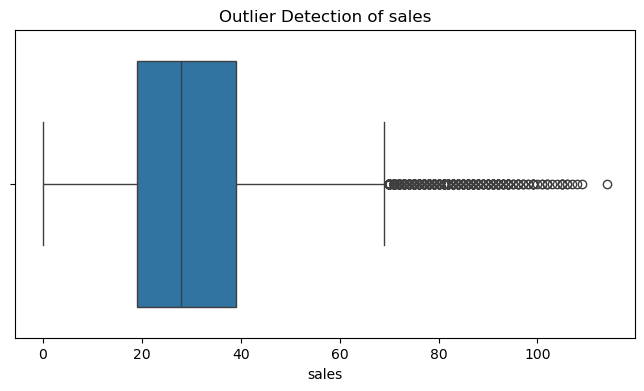

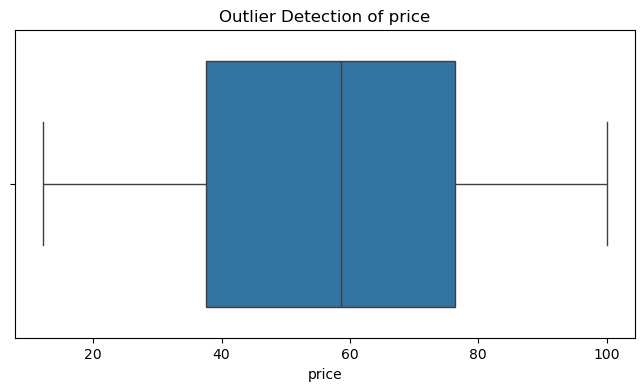

In [8]:
# visualisasi outlier
for col in ['sales', 'price']:
    
    plt.figure(figsize=(8,4))
    
    sns.boxplot(x=df[col])
    
    plt.title(f'Outlier Detection of {col}')
    
    plt.show()

Insight:
- Outlier tidak dihapus karena masih merepresentasikan kondisi penjualan yang valid.
- Untuk mengurangi pengaruh nilai ekstrem, digunakan RobustScaler pada tahap feature scaling.

# 6. Handling Skewness

Transformasi dilakukan pada fitur yang memiliki skewness tinggi agar distribusi data menjadi lebih stabil.

In [9]:
# menghitung skewness
df[['sales', 'price']].skew() 

sales    0.812499
price    0.014459
dtype: float64

In [10]:
# fitur yang akan ditransformasi
skewed_features = ['sales']

In [11]:
# log transformation
for col in skewed_features:
    
    df[col] = np.log1p(df[col])

Insight:
- Log transformation digunakan untuk mengurangi skewness pada distribusi data.

# 7. Feature Scaling

Feature scaling dilakukan agar seluruh fitur numerik memiliki skala yang lebih stabil dan tidak terlalu dipengaruhi oleh outlier.

In [12]:
# memilih kolom yang akan dilakukan scaling
scale_cols = ['sales', 'price']

scale_cols

['sales', 'price']

In [13]:
# robust scaling
scaler = RobustScaler()

df[scale_cols] = scaler.fit_transform(df[scale_cols])

Insight:
- RobustScaler digunakan karena dataset masih memiliki sejumlah outlier sehingga scaling menjadi lebih stabil terhadap nilai ekstrem.
- Scaling hanya dilakukan pada variabel sales dan price.

# 9. Final Data Checking

In [14]:
# informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54750 entries, 0 to 54749
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      54750 non-null  object 
 1   store_id  54750 non-null  object 
 2   item_id   54750 non-null  object 
 3   sales     54750 non-null  float64
 4   price     54750 non-null  float64
 5   promo     54750 non-null  int64  
 6   weekday   54750 non-null  int64  
 7   month     54750 non-null  int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 3.3+ MB


In [15]:
# menampilkan dataset
df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2021-01-01,store_1,item_1,0.351472,-0.96484,0,4,1
1,2021-01-02,store_1,item_1,0.351472,-0.96484,0,5,1
2,2021-01-03,store_1,item_1,0.311944,-0.96484,0,6,1
3,2021-01-04,store_1,item_1,0.534336,-0.96484,0,0,1
4,2021-01-05,store_1,item_1,0.896907,-0.96484,0,1,1


In [16]:
# statistik deskriptif setelah preprocessing
df.describe()

,sales,price,promo,weekday,month
count,54750.000000,54750.000000,54750.000000,54750.000000,54750.000000
mean,-0.082200,-0.065730,0.099233,3.005479,6.526027
std,0.734683,0.623126,0.298977,2.000467,3.447883
min,-4.857981,-1.200103,0.000000,0.000000,1.000000
25%,-0.536053,-0.542916,0.000000,1.000000,4.000000
50%,0.000000,0.000000,0.000000,3.000000,7.000000
75%,0.463947,0.457084,0.000000,5.000000,10.000000
max,1.987509,1.069545,1.000000,6.000000,12.000000


# 9. Save Preprocessed Dataset

In [17]:
# menyimpan dataset preprocessing
df.to_csv('../data/preprocessed_data.csv', index=False)